# Structure Output Agent
A structure output agent in Langchain (or other LLM frameworks) refers to an agent that produces responses in a specific structured format, such as JSON, dictionaries or other structured data types. 
These agents are particularly useful when you want to ensure that your responses confirm to a defined schema, making it easier to parse validate and utilize in downstream applications. 

## Why to use a Structured Output Agent?

**1. Controlled Responses:** Ensures that output follows a specific format, reducing ambiguity. 


**2. Data Validation:** Useful when you want the model output to fit predefined structures like for APIs or database entries. 


**3. Automation:** Makes integration with system like dashboards, ETL pipelines or bussiness workflow easier.  

In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from langgraph.graph import MessagesState, StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [9]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name = "llama-3.1-8b-instant")

In [10]:
# tavily is used for calling web
tavily_tool = TavilySearchResults()

In [11]:
@tool
def get_city_details(prompt):
    "Should do a web search to find the required city details"
    response = tavily_tool.invoke(prompt)
    return response

In [12]:
tools = [get_city_details]

In [13]:
model_with_tools = llm.bind_tools(tools)

In [14]:
class CityDetails(BaseModel):
    """Respond to the user with this"""
    state_name: str = Field(description = "State name of the city")
    state_capital: str = Field(description="State capital of the city")
    country_name: str = Field(description= "Country name of the city")
    country_capital: str = Field(description="Country capital of the city")

In [15]:
# Inherit 'messages' key from MessagesState, which is a list of chat messages
class AgentState(MessagesState):
    # Final structured response from the agent
    final_response: CityDetails

In [16]:
model_with_structured_output = llm.with_structured_output(CityDetails)

In [17]:
def call_model(state: AgentState):
    print(f"this is 01 input from call model {state}")
    response = model_with_tools.invoke(state['messages'])
    print(f"this is 02 response from call model {response}")
    # We return a list, because this will get added to existing list
    return {"messages": [response]}

In [18]:
def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]

    # If there is no function call, then we respond to the user
    if not last_message.tool_calls:
        return "respond"
    # Otherwise if there is, we continue with the tool
    else:
        return "continue"

In [19]:
def respond(state: AgentState):
    print(f"here is 03 state from respond {state}")
    response = model_with_structured_output.invoke([HumanMessage(content = state['messages'][-1].content)])
    # We return a list, because this will get added to existing list
    print(f"this is 04 response from respond{response}")
    return {"final_response": response}

In [26]:
def assistant(state: MessagesState):
    
    response = model_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }

In [27]:
workflow = StateGraph(MessagesState)

# Nodes
workflow.add_node("llm", assistant)

tool_node = ToolNode(tools=tools)
workflow.add_node("tools", tool_node)

workflow.add_node("respond", respond)

# Entry Point
workflow.set_entry_point("llm")

# Conditional Edges
workflow.add_conditional_edges(
    "llm",
    should_continue,
    {
        "continue": "tools",
        "respond": "respond",
    },
)

# Normal Edges
workflow.add_edge("tools", "llm")
workflow.add_edge("respond", END)

# Compile the workflow into an executable graph
graph = workflow.compile()

agent_state = AgentState(messages=[HumanMessage(content="What is the state and country of the city Paris?")])

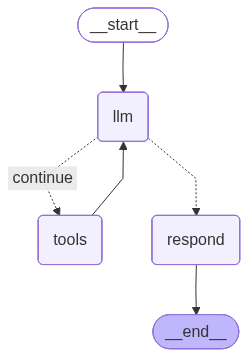

In [28]:
from IPython.display import Image, display
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
answer = graph.invoke({"messages": [HumanMessage(content="Tell me about the city details for gwalior?")]})

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=get_city_details>{"prompt": "gwalior"}'}}

In [ ]:
answer